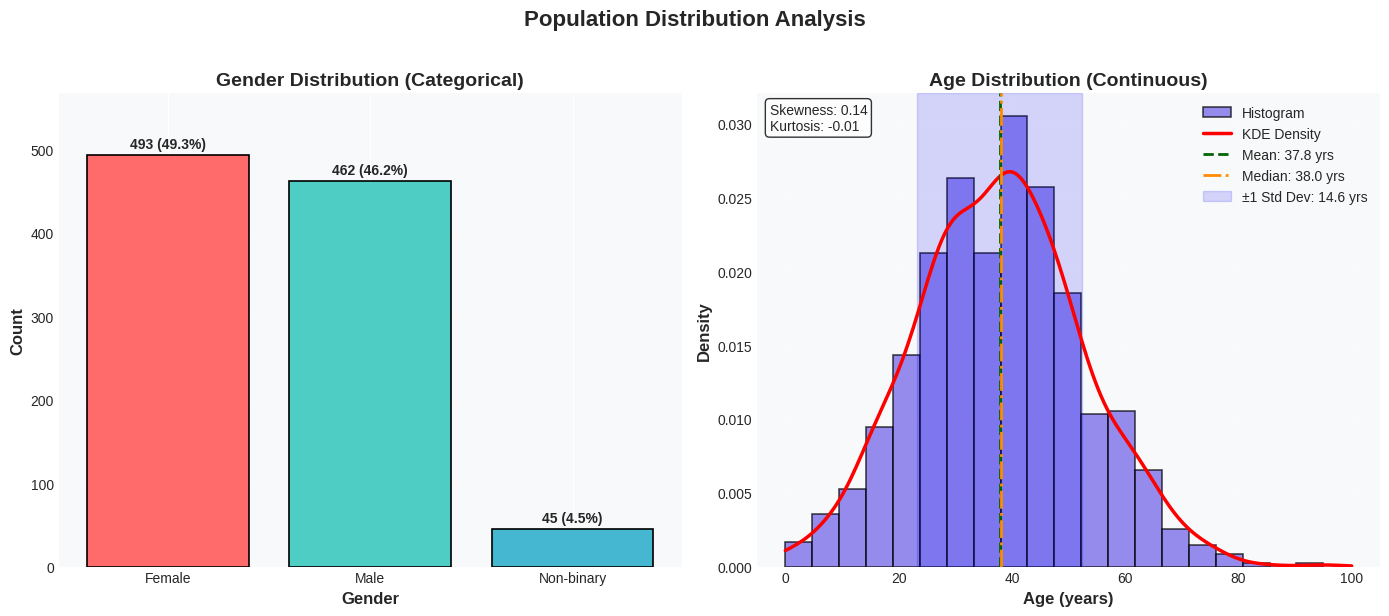

POPULATION SUMMARY STATISTICS
Total Population: 1000

Age Statistics:
  Mean: 37.81 years
  Median: 38.00 years
  Std Dev: 14.64 years
  Min: 0 years
  Max: 95 years

Gender Distribution:
  Female: 493 (49.3%)
  Male: 462 (46.2%)
  Non-binary: 45 (4.5%)


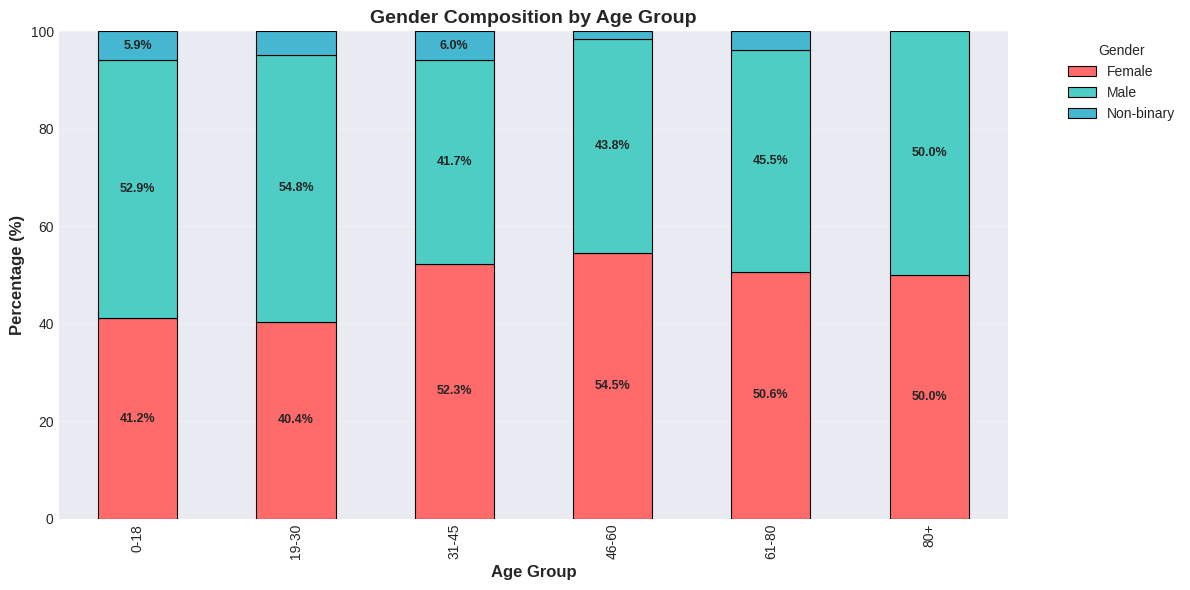

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Generate synthetic population data
np.random.seed(42)
n_people = 1000

# Generate ages (normal distribution with some skew)
ages = np.random.normal(38, 15, n_people)
ages = np.clip(ages, 0, 100).astype(int)  # Clip to reasonable age range

# Generate genders with slight imbalance
genders = np.random.choice(['Male', 'Female', 'Non-binary'],
                          size=n_people,
                          p=[0.48, 0.48, 0.04])

# Create DataFrame
df = pd.DataFrame({
    'Age': ages,
    'Gender': genders
})

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Population Distribution Analysis', fontsize=16, fontweight='bold', y=1.02)

# ============ BAR CHART: Gender Distribution ============
gender_counts = df['Gender'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax1.bar(gender_counts.index, gender_counts.values, color=colors, edgecolor='black', linewidth=1.2)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)} ({height/n_people*100:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_xlabel('Gender', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
ax1.set_title('Gender Distribution (Categorical)', fontsize=14, fontweight='bold')
ax1.set_ylim(0, max(gender_counts.values) * 1.15)
ax1.grid(axis='y', alpha=0.3)

# Add a subtle background color
ax1.set_facecolor('#f8f9fa')

# ============ HISTOGRAM: Age Distribution ============
# Create histogram with KDE
n, bins, patches = ax2.hist(df['Age'], bins=20, alpha=0.7,
                            edgecolor='black', linewidth=1.2,
                            color='#6C5CE7', density=True, label='Histogram')

# Add KDE (Kernel Density Estimate)
kde = stats.gaussian_kde(df['Age'])
x_range = np.linspace(0, 100, 200)
ax2.plot(x_range, kde(x_range), 'r-', linewidth=2.5, label='KDE Density')

# Add vertical lines for mean and median
mean_age = df['Age'].mean()
median_age = df['Age'].median()
ax2.axvline(mean_age, color='darkgreen', linestyle='--', linewidth=2,
            label=f'Mean: {mean_age:.1f} yrs')
ax2.axvline(median_age, color='darkorange', linestyle='-.', linewidth=2,
            label=f'Median: {median_age:.1f} yrs')

# Add shaded area for standard deviation
std_age = df['Age'].std()
ax2.axvspan(mean_age - std_age, mean_age + std_age, alpha=0.15,
            color='blue', label=f'±1 Std Dev: {std_age:.1f} yrs')

ax2.set_xlabel('Age (years)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Density', fontsize=12, fontweight='bold')
ax2.set_title('Age Distribution (Continuous)', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(alpha=0.3)
ax2.set_facecolor('#f8f9fa')

# Add statistical annotations
stats_text = f'Skewness: {stats.skew(df["Age"]):.2f}\nKurtosis: {stats.kurtosis(df["Age"]):.2f}'
ax2.text(0.02, 0.98, stats_text, transform=ax2.transAxes,
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Additional summary statistics
print("=" * 50)
print("POPULATION SUMMARY STATISTICS")
print("=" * 50)
print(f"Total Population: {n_people}")
print(f"\nAge Statistics:")
print(f"  Mean: {mean_age:.2f} years")
print(f"  Median: {median_age:.2f} years")
print(f"  Std Dev: {std_age:.2f} years")
print(f"  Min: {df['Age'].min()} years")
print(f"  Max: {df['Age'].max()} years")
print(f"\nGender Distribution:")
for gender, count in gender_counts.items():
    print(f"  {gender}: {count} ({count/n_people*100:.1f}%)")
print("=" * 50)

# Create a more detailed version with age groups by gender
fig, ax = plt.subplots(figsize=(12, 6))

# Create age groups
age_bins = [0, 18, 30, 45, 60, 80, 100]
age_labels = ['0-18', '19-30', '31-45', '46-60', '61-80', '80+']
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

# Create stacked bar chart
age_gender_pivot = pd.crosstab(df['Age_Group'], df['Gender'], normalize='index') * 100
age_gender_pivot.plot(kind='bar', stacked=True, ax=ax, color=['#FF6B6B', '#4ECDC4', '#45B7D1'],
                     edgecolor='black', linewidth=0.8)

ax.set_xlabel('Age Group', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Gender Composition by Age Group', fontsize=14, fontweight='bold')
ax.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 100)

# Add percentage labels on bars
for container in ax.containers:
    ax.bar_label(container, labels=[f'{v:.1f}%' if v > 5 else '' for v in container.datavalues],
                label_type='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()